# Funcion de Rastringin

$f(\vec{x}) = 10n + \sum_{i=1}^{n} (x_i^2 + 10cos(2\pi x_i))$



## Autores:
- Fernando Leon Franco
- Rodrigo Mendoza Rodríguez





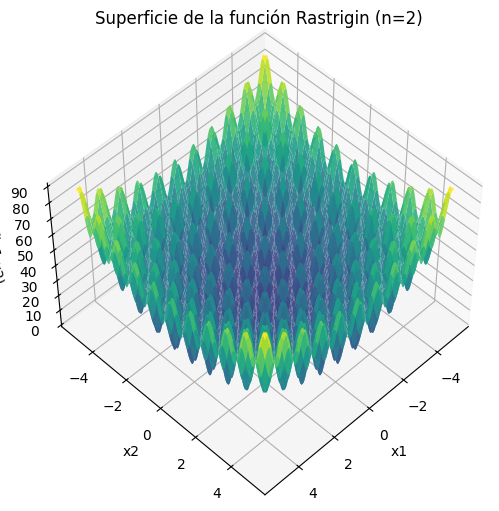

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Imin, Imax = -5.12, 5.12
res = 200  # resolución de la malla

x = np.linspace(Imin, Imax, res)
y = np.linspace(Imin, Imax, res)
X, Y = np.meshgrid(x, y)

Z = 10*2 + (X**2 + 10*np.cos(2*np.pi*X)) + (Y**2 + 10*np.cos(2*np.pi*Y))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax.set_title('Superficie de la función Rastrigin (n=2)')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1,x2)')
ax.view_init(elev=50, azim=45)
plt.show()


In [ ]:

def inicioPob(n,l,Imin,Imax):
    poblacion = np.random.uniform(Imin, Imax, (n,l))
    return poblacion

def rastrigin(x):
    return 10 * len(x) + sum([(xi**2 + 10 * np.cos(2 * np.pi * xi)) for xi in x])

def fitness(poblacion):
    evaluacion = []
    for individuo in poblacion:
        evaluacion.append(rastrigin(individuo))
    return np.array(evaluacion)

def BUMDA_media_stds(poblacion, g, Imin, Imax, beta=1):
    g = -g

    m, d = poblacion.shape

    exp_g = np.exp(beta * g - np.max(beta * g))
    Z = m / ((Imax - Imin) * np.sum(exp_g) + 1e-9)
    g_norm = exp_g / (np.sum(exp_g) + 1e-12)

    mu = np.zeros(d)
    sigma = np.zeros(d)

    for j in range(d):
        xj = poblacion[:, j]

        mu_term1 = (1.0 / (Z * beta)) * np.sum(exp_g * xj)
        denum_mu = (m / ((Imax - Imin) * beta)) + np.sum(g)
        mu_term2 = np.sum(g * xj) / (denum_mu + 1e-12)
        mu[j] = mu_term1 - mu_term2

        var_term1 = (1.0 / (Z * beta)) * np.sum(exp_g * (xj - mu[j])**2)
        var_term2 = np.sum(g_norm * (xj - mu[j])**2)
        varianza = var_term1 + var_term2


        sigma[j] = np.sqrt(max(varianza, 1e-9))
        sigma[j] = max(sigma[j], 1e-3)

    return mu, sigma

def seleccion_ranking(poblacion, ps, Imin, Imax):
    r, c = poblacion.shape
    nueva_poblacion = np.zeros((r, c))
    n = int(ps * r)

    aptitud = fitness(poblacion).reshape(r, 1)
    pob_ampliada = np.concatenate((poblacion, aptitud), axis=1)
    indices = np.argsort(pob_ampliada[:, -1])
    pob_ordenada = pob_ampliada[indices]
    elites = pob_ordenada[:n, :c]

    medias, desviaciones = BUMDA_media_stds(elites, pob_ordenada[:n, -1], Imin, Imax)

    for i in range(r):
        if i < n:
            nueva_poblacion[i] = elites[i]
        else:
            nuevo = [np.random.normal(m, s) for m, s in zip(medias, desviaciones)]
            nueva_poblacion[i] = np.clip(nuevo, Imin, Imax)

    return nueva_poblacion



Mejor individuo encontrado: [-0.5247548  -0.49602046]
Valor mínimo encontrado: 0.6452479759128202


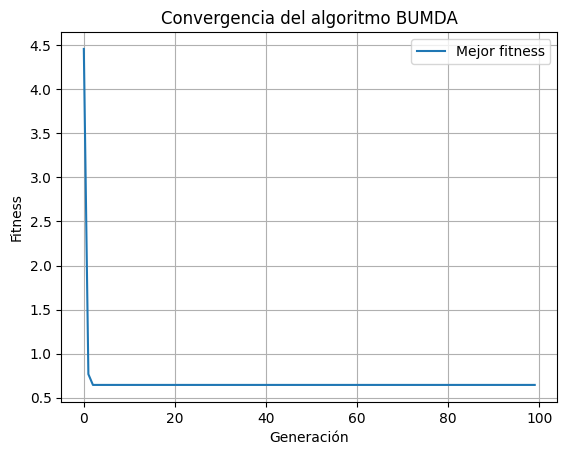

In [ ]:
# Parámetros
n = 100
l = 2
generaciones = 100
ps = 0.5
Imin, Imax = -5.12, 5.12

hist_best = []
P = inicioPob(n, l, Imin, Imax)

for gen in range(generaciones):
    fit = fitness(P)

    hist_best.append(np.min(fit))
    P = seleccion_ranking(P, ps, Imin, Imax)

# Resultados finales
fit_final = fitness(P)
mejor = P[np.argmin(fit_final)]
print("\nMejor individuo encontrado:", mejor)
print("Valor mínimo encontrado:", np.min(fit_final))

# Gráfica
plt.figure()
plt.plot(hist_best, label="Mejor fitness")
plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.title("Convergencia del algoritmo BUMDA")
plt.legend()
plt.grid(True)
plt.show()


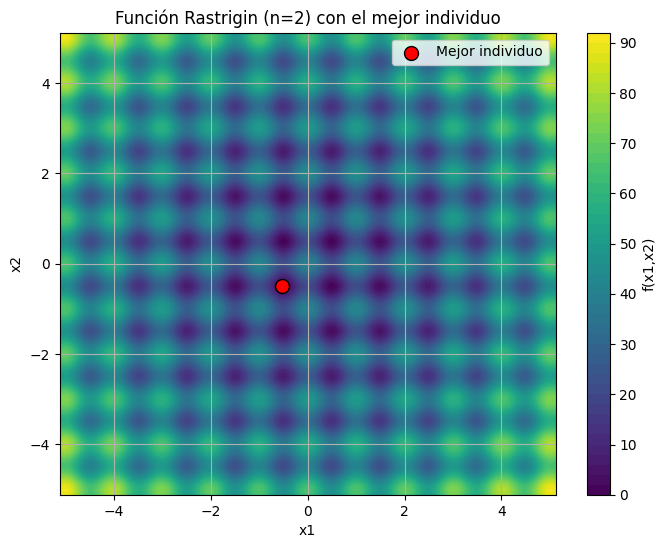

In [ ]:
Imin, Imax = -5.12, 5.12
res = 200

x = np.linspace(Imin, Imax, res)
y = np.linspace(Imin, Imax, res)
X, Y = np.meshgrid(x, y)

Z = 10*2 + (X**2 + 10*np.cos(2*np.pi*X)) + (Y**2 + 10*np.cos(2*np.pi*Y))

plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='f(x1,x2)')
plt.scatter(mejor[0], mejor[1], color='red', label='Mejor individuo', s=100, edgecolors='black')
plt.title('Función Rastrigin (n=2) con el mejor individuo')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

# Funcion de Rastringin
$f(\vec{x}) = 10n + \sum_{i=1}^{n} (x_i^2 - 10cos(2\pi x_i))$

In [ ]:
def inicioPob(n,l,Imin,Imax):
    poblacion = np.random.uniform(Imin, Imax, (n,l))
    return poblacion

def rastrigin(x):
    return 10 * len(x) + sum([(xi**2 - 10 * np.cos(2 * np.pi * xi)) for xi in x])

def fitness(poblacion):
    evaluacion = []
    for individuo in poblacion:
        evaluacion.append(rastrigin(individuo))
    return np.array(evaluacion)

def BUMDA_media_stds(poblacion, g, Imin, Imax, beta=1):
    g = -g

    m, d = poblacion.shape

    exp_g = np.exp(beta * g - np.max(beta * g))
    Z = m / ((Imax - Imin) * np.sum(exp_g) + 1e-9)
    g_norm = exp_g / (np.sum(exp_g) + 1e-12)

    mu = np.zeros(d)
    sigma = np.zeros(d)

    for j in range(d):
        xj = poblacion[:, j]

        mu_term1 = (1.0 / (Z * beta)) * np.sum(exp_g * xj)
        denum_mu = (m / ((Imax - Imin) * beta)) + np.sum(g)
        mu_term2 = np.sum(g * xj) / (denum_mu + 1e-12)
        mu[j] = mu_term1 - mu_term2

        var_term1 = (1.0 / (Z * beta)) * np.sum(exp_g * (xj - mu[j])**2)
        var_term2 = np.sum(g_norm * (xj - mu[j])**2)
        varianza = var_term1 + var_term2

        sigma[j] = np.sqrt(max(varianza, 1e-9))
        sigma[j] = max(sigma[j], 1e-3)

    return mu, sigma


def seleccion_ranking(poblacion, ps, Imin, Imax):
    r, c = poblacion.shape
    nueva_poblacion = np.zeros((r, c))
    n = int(ps * r)

    aptitud = fitness(poblacion).reshape(r, 1)
    pob_ampliada = np.concatenate((poblacion, aptitud), axis=1)
    indices = np.argsort(pob_ampliada[:, -1])
    pob_ordenada = pob_ampliada[indices]
    elites = pob_ordenada[:n, :c]

    medias, desviaciones = BUMDA_media_stds(elites, pob_ordenada[:n, -1], Imin, Imax)

    for i in range(r):
        if i < n:
            nueva_poblacion[i] = elites[i]
        else:
            nuevo = [np.random.normal(m, s) for m, s in zip(medias, desviaciones)]
            nueva_poblacion[i] = np.clip(nuevo, Imin, Imax)

    return nueva_poblacion


Mejor individuo encontrado: [ 0.01319714 -0.01548964]
Valor mínimo encontrado: 0.0820958050792342


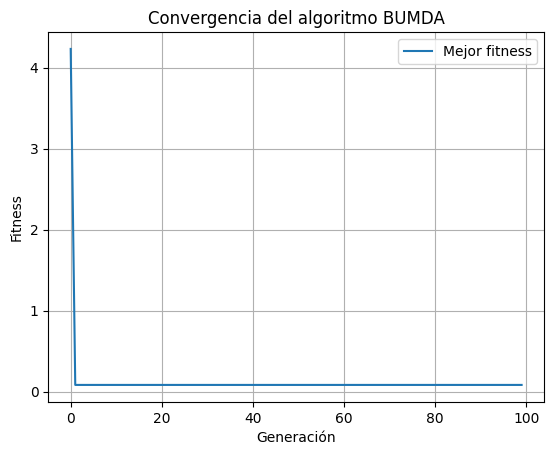

In [ ]:
# Parámetros
n = 100
l = 2
generaciones = 100
ps = 0.5
Imin, Imax = -5.12, 5.12

hist_best = []
P = inicioPob(n, l, Imin, Imax)

for gen in range(generaciones):
    fit = fitness(P)

    fit = np.nan_to_num(fit, nan=1e6, posinf=1e6, neginf=1e6)
    fit = np.clip(fit, -1e3, 1e3)

    hist_best.append(np.min(fit))
    P = seleccion_ranking(P, ps, Imin, Imax)

# Resultados finales
fit_final = fitness(P)
mejor = P[np.argmin(fit_final)]
print("\nMejor individuo encontrado:", mejor)
print("Valor mínimo encontrado:", np.min(fit_final))

# Gráfica
plt.figure()
plt.plot(hist_best, label="Mejor fitness")
plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.title("Convergencia del algoritmo BUMDA")
plt.legend()
plt.grid(True)
plt.show()


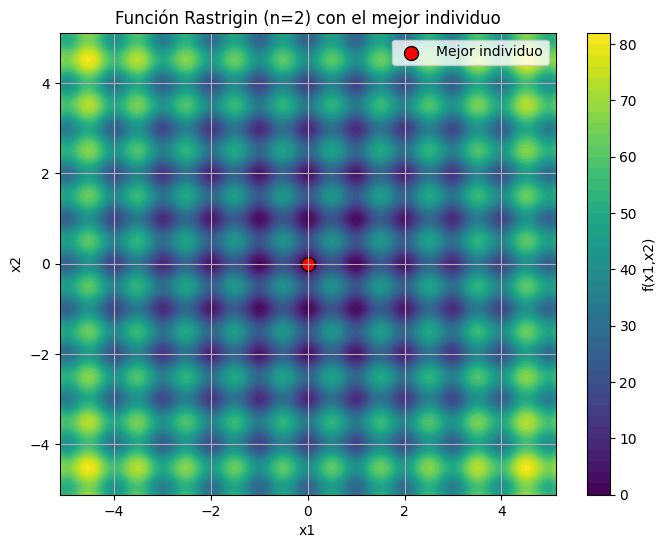

In [ ]:
Imin, Imax = -5.12, 5.12
res = 200

x = np.linspace(Imin, Imax, res)
y = np.linspace(Imin, Imax, res)
X, Y = np.meshgrid(x, y)

Z = 10*2 + (X**2 - 10*np.cos(2*np.pi*X)) + (Y**2 - 10*np.cos(2*np.pi*Y))

plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(contour, label='f(x1,x2)')
plt.scatter(mejor[0], mejor[1], color='red', label='Mejor individuo', s=100, edgecolors='black')
plt.title('Función Rastrigin (n=2) con el mejor individuo')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()